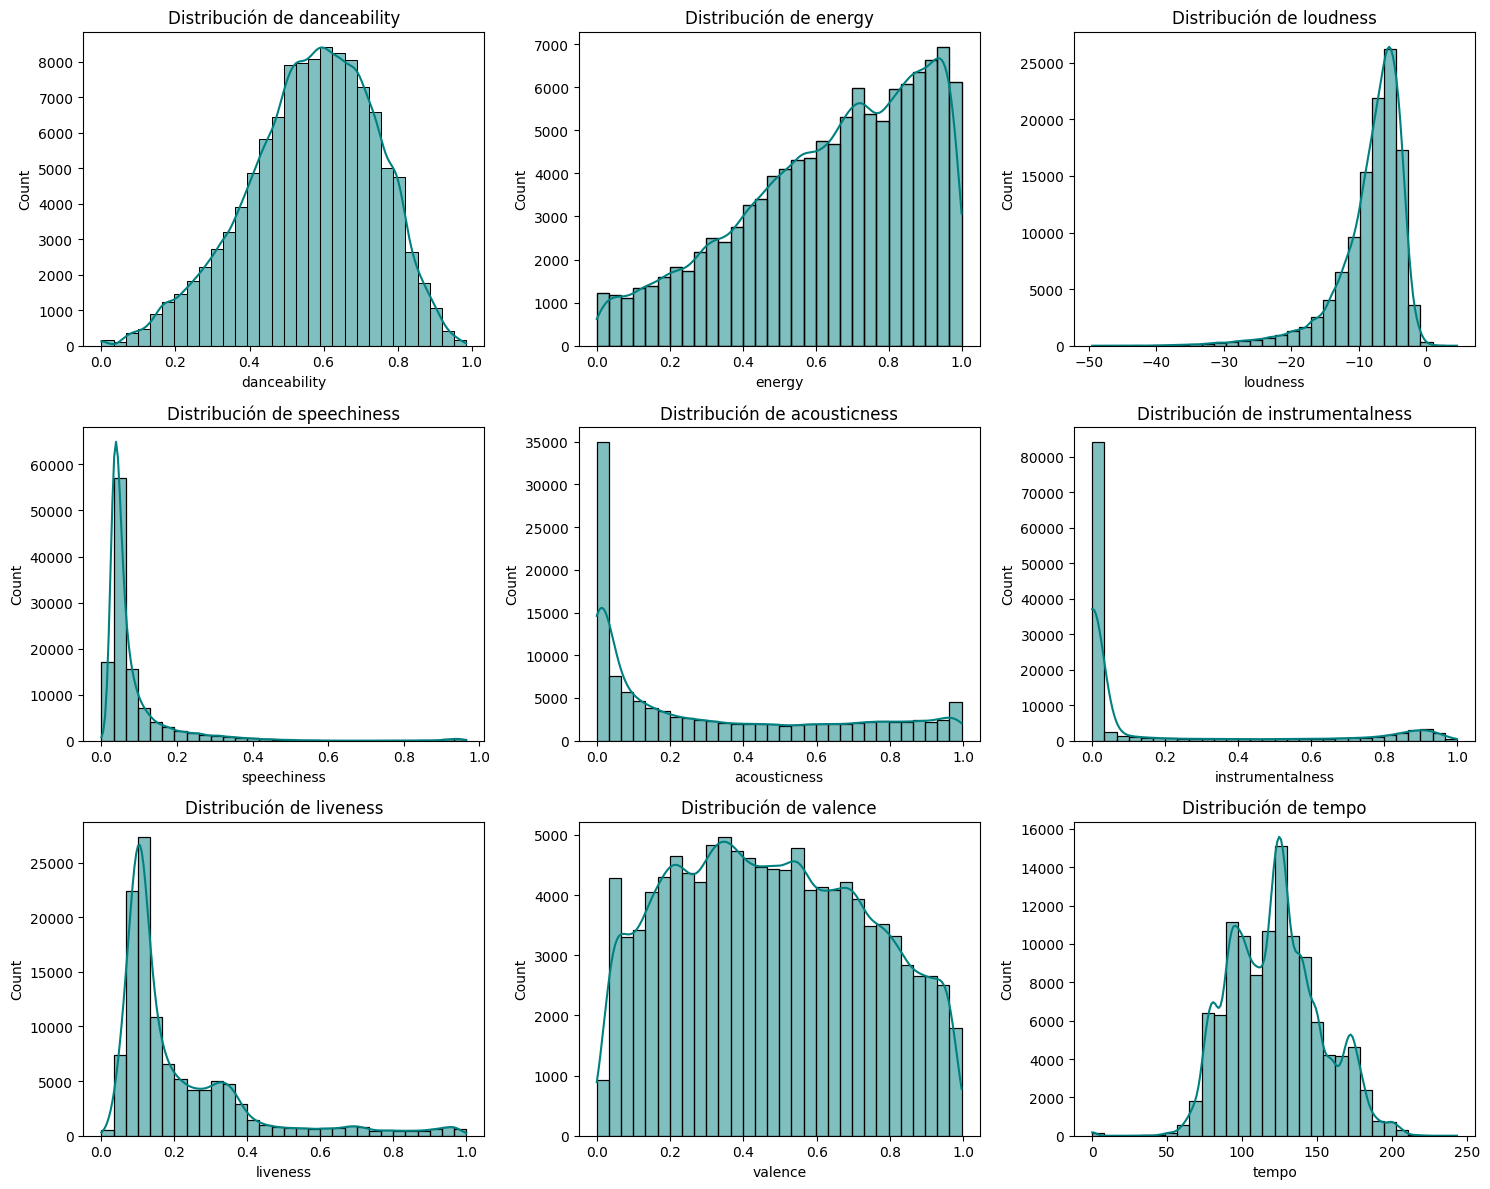

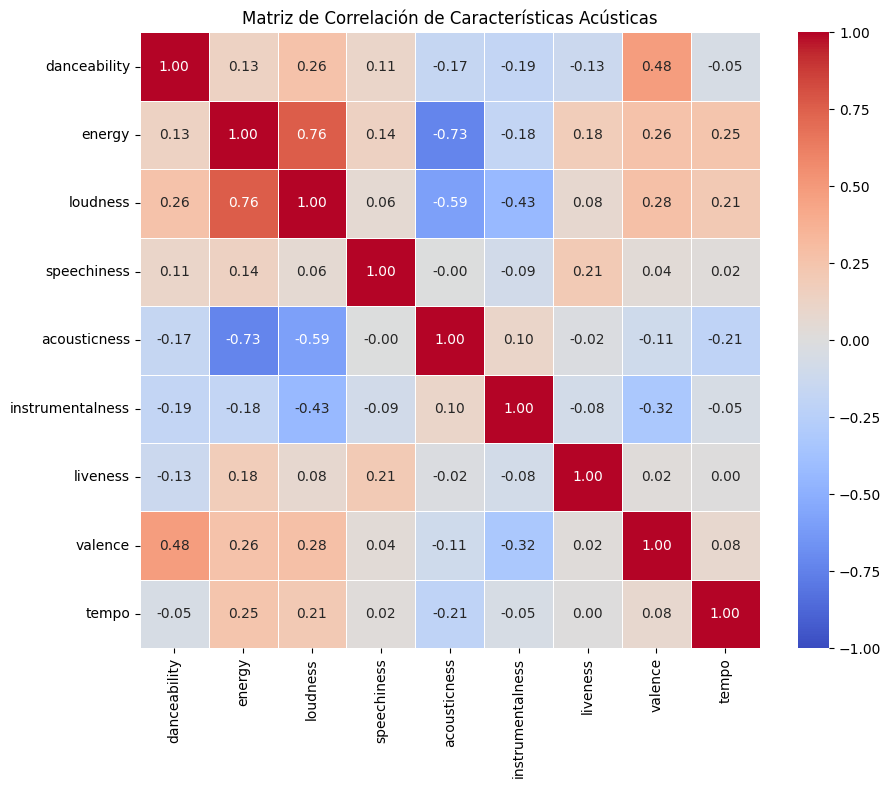

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/basti/proyecto_cd/data/raw/spotify-tracks-dataset.csv", sep=",")

# Eliminamos las columnas de índices redundantes y cualquier fila con valores nulos
df_cleaned = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])
df_cleaned = df_cleaned.dropna()

# Features
acoustic_features = ['danceability', 'energy', 'loudness', 'speechiness',
                     'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# GRÁFICO 1: Distribuciones de las variables
plt.figure(figsize=(15, 12))
for i, feature in enumerate(acoustic_features, 1):
    plt.subplot(3, 3, i)
    # Usamos histplot para ver la distribución y la curva KDE (densidad)
    sns.histplot(df_cleaned[feature], bins=30, kde=True, color='teal')
    plt.title(f'Distribución de {feature}')
    plt.tight_layout()

plt.show()

# GRÁFICO 2: Matriz de Correlación
plt.figure(figsize=(10, 8))
# Calculamos la correlación de Pearson entre las variables acústicas
corr_matrix = df_cleaned[acoustic_features].corr()

# Creamos un mapa de calor (heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Características Acústicas')

plt.show()

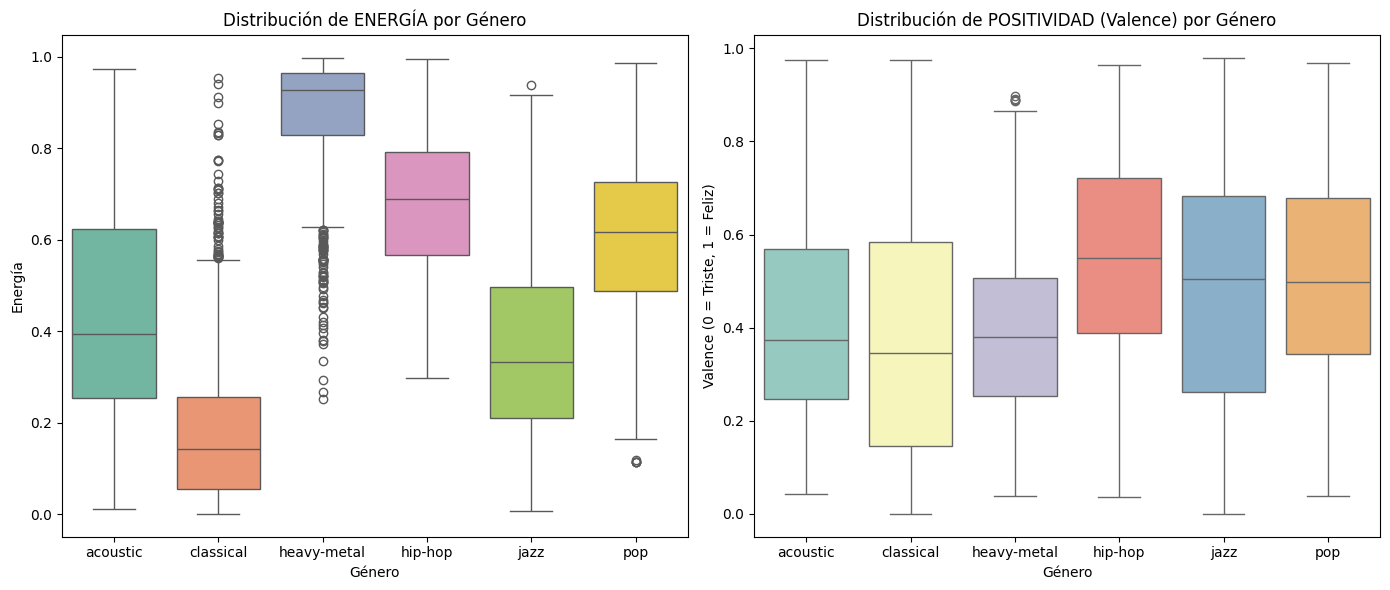

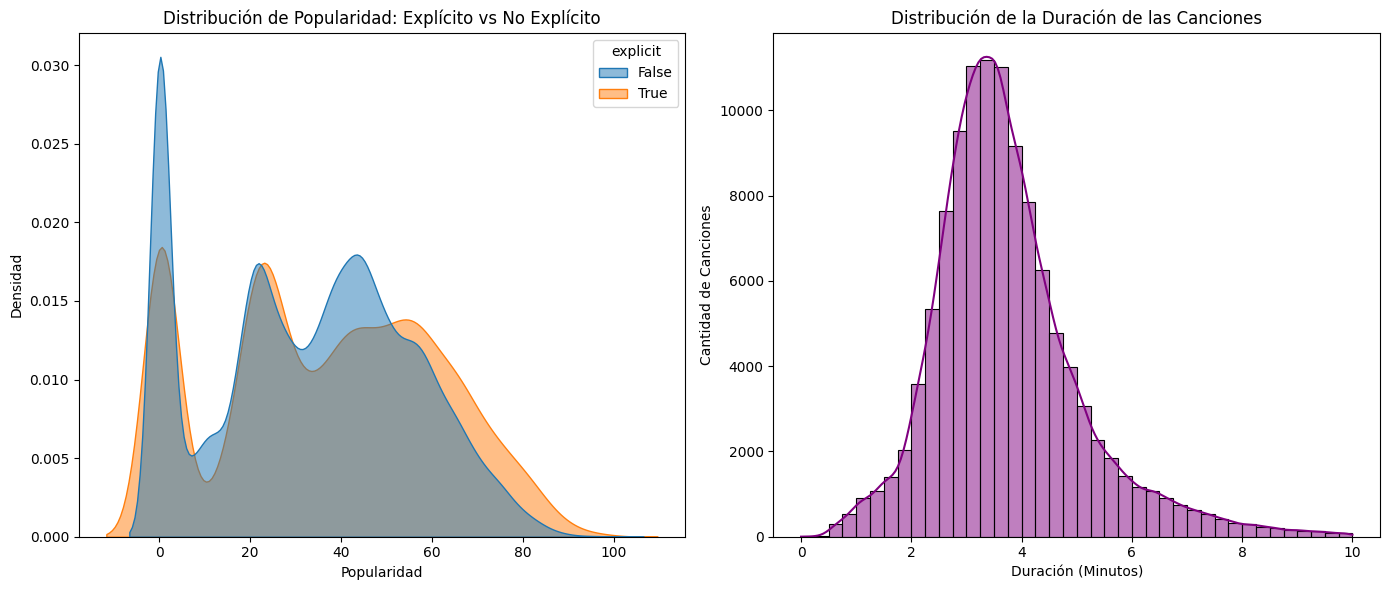

In [13]:
import seaborn as sns

df_raw = df

# ANÁLISIS POR GÉNERO (Perfiles Acústicos)
# Seleccionamos 6 géneros bien contrastados para comparar
generos_seleccionados = ['classical', 'heavy-metal', 'pop', 'jazz', 'hip-hop', 'acoustic']
df_generos = df_raw[df_raw['track_genre'].isin(generos_seleccionados)]

plt.figure(figsize=(14, 6))

# Subplot 1: Energía por Género
plt.subplot(1, 2, 1)
sns.boxplot(x='track_genre', y='energy', data=df_generos, palette='Set2', hue='track_genre', legend=False)
plt.title('Distribución de ENERGÍA por Género')
plt.xlabel('Género')
plt.ylabel('Energía')

# Subplot 2: Positividad (Valence) por Género
plt.subplot(1, 2, 2)
sns.boxplot(x='track_genre', y='valence', data=df_generos, palette='Set3', hue='track_genre', legend=False)
plt.title('Distribución de POSITIVIDAD (Valence) por Género')
plt.xlabel('Género')
plt.ylabel('Valence (0 = Triste, 1 = Feliz)')

plt.tight_layout()
plt.show()

# IMPACTO DEL CONTENIDO EXPLÍCITO Y DURACIÓN
plt.figure(figsize=(14, 6))

# Subplot 1: Popularidad vs Contenido Explícito
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_raw, x='popularity', hue='explicit', fill=True, common_norm=False, alpha=0.5)
plt.title('Distribución de Popularidad: Explícito vs No Explícito')
plt.xlabel('Popularidad')
plt.ylabel('Densidad')

# Subplot 2: Distribución de la Duración (Convertida a minutos)
# Creamos una columna temporal en minutos
df_raw['duration_mins'] = df_raw['duration_ms'] / 60000
plt.subplot(1, 2, 2)
# Limitamos el eje X a 10 minutos para que los outliers extremos no rompan el gráfico
sns.histplot(df_raw[df_raw['duration_mins'] < 10]['duration_mins'], bins=40, kde=True, color='purple')
plt.title('Distribución de la Duración de las Canciones')
plt.xlabel('Duración (Minutos)')
plt.ylabel('Cantidad de Canciones')

plt.tight_layout()
plt.show()

Distribución de energía por genero (boxplot):
* El diagrama de cajas evidencia que la característica acústica de "energía" tiene una fuerte correlación con el género musical. Los géneros de nicho (heavy-metal, classical, acoustic) tienen energías muy estrictas y definidas. Por el contrario, los géneros masivos (pop, hip-hop) son mucho más amplios y abarcan un espectro de energía mucho mayor, lo que indica que el género por sí solo no basta para determinar la intensidad de una canción pop.

Distribución de positividad por género (boxplot):
* El diagrama demuestra que el valence (positividad/estado de ánimo) es una variable mucho más dispersa y subjetiva dentro de los géneros que la energía. La mayoría de los géneros comerciales y populares (pop, hip-hop, jazz) contienen todo el espectro emocional humano. Esto confirma que el nombre del género musical no es un buen indicador para saber si una canción será triste o alegre; una canción de pop puede ser igual de melancólica que una canción acústica.

Distribución de popularidad: Explícito vs No Explícito (gráfico de densidad):
* El gráfico de densidad revela un contraste drástico en el comportamiento de ambos grupos. El inmenso catálogo de música "No Explícita" está fuertemente diluido por miles de pistas que nadie escucha (ruido blanco, covers desconocidos, pistas de relleno). Por el contrario, las canciones etiquetadas como "Explícitas" logran esquivar casi por completo la zona de popularidad nula y tienden a concentrarse por defecto en los rangos de éxito medio y alto. En términos estadísticos dentro de esta muestra, una canción explícita tiene una probabilidad mucho mayor de ser moderadamente o altamente popular que una pista sin dicha etiqueta.

Distribución de duración de las canciones (histograma):
* El histograma evidencia una estandarización brutal en la producción musical. La concentración masiva de pistas alrededor de los 3.5 minutos refleja el formato clásico de "radio edit" que ha sido heredado y optimizado por la era del streaming. Los artistas y productores apuntan casi matemáticamente a este rango de tiempo, probablemente para maximizar las reproducciones (streams) y mantener la retención de la audiencia, dejando las pistas de más de 5 minutos reservadas para géneros específicos (como la música clásica o variaciones de jazz/metal) o decisiones artísticas menos comerciales.

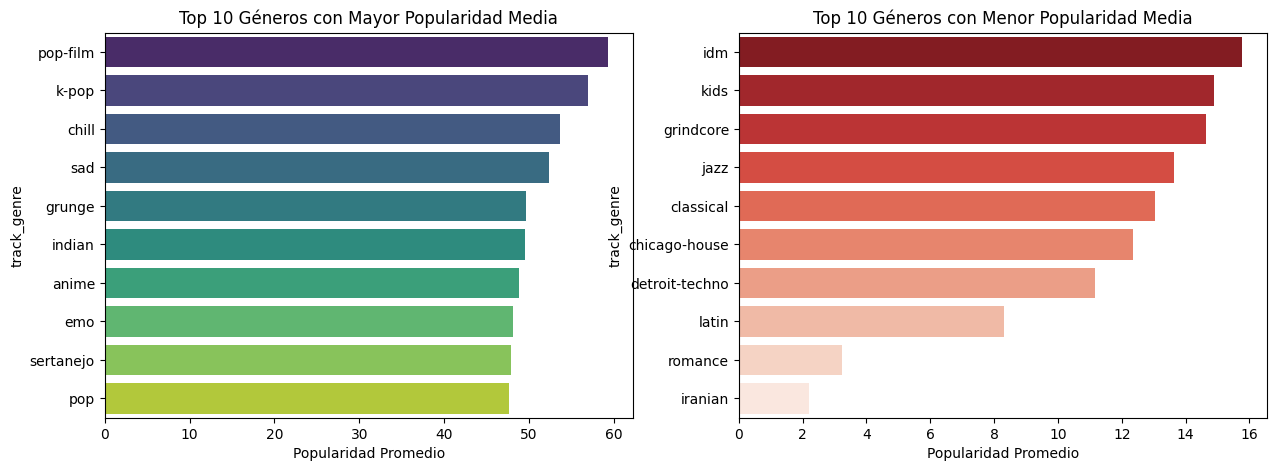

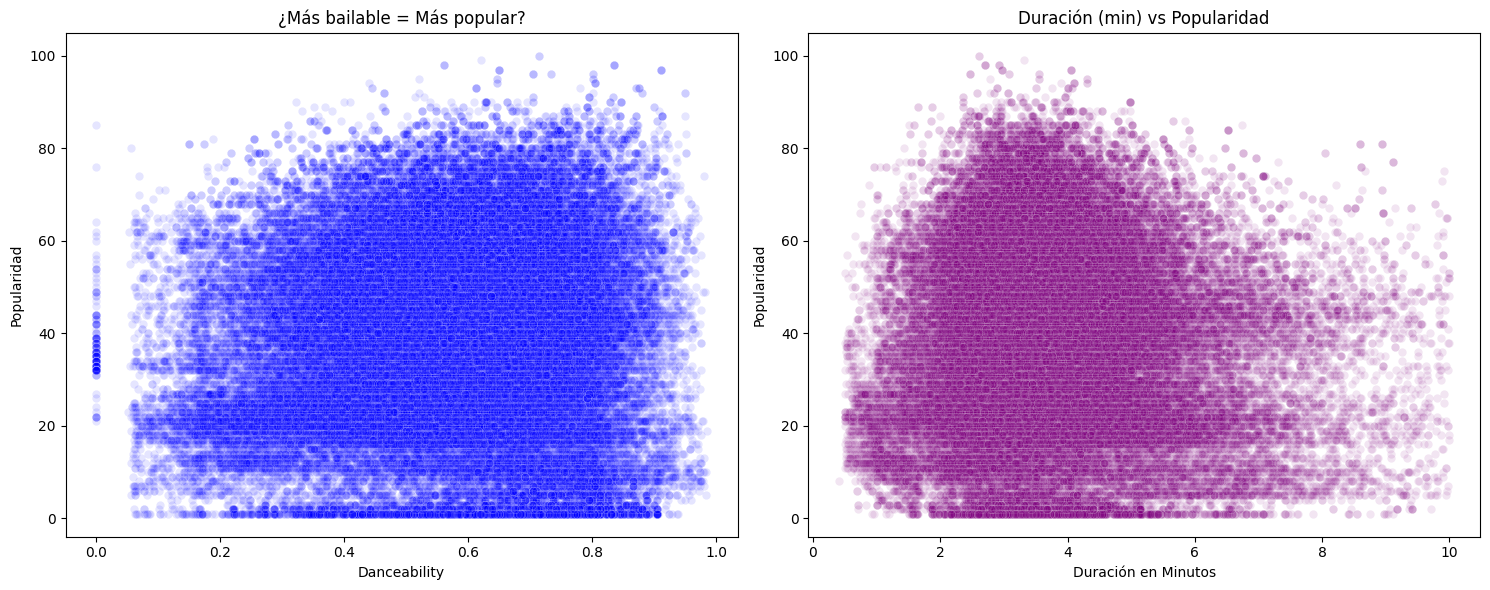

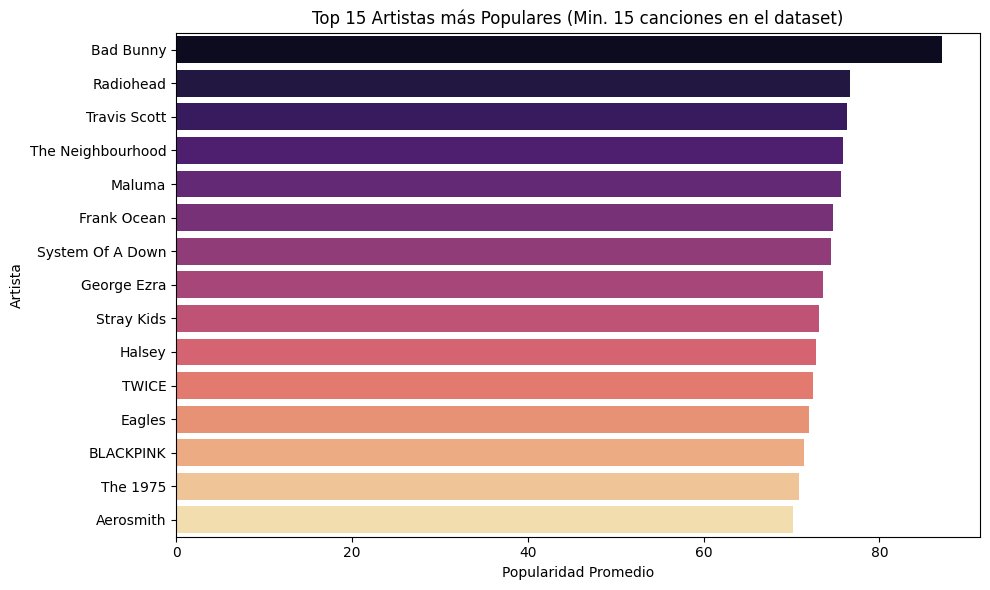

In [12]:
df_raw.dropna(subset=['artists', 'track_genre'])

# Convertir duración a minutos para que sea legible
df_raw['duration_mins'] = df_raw['duration_ms'] / 60000

# GÉNEROS MÁS Y MENOS POPULARES
# Calculamos la popularidad media por género
pop_por_genero = df_raw.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
# Graficamos el Top 10
plt.subplot(1, 2, 1)
sns.barplot(x=pop_por_genero.head(10).values, y=pop_por_genero.head(10).index, palette='viridis', hue=pop_por_genero.head(10).index, legend=False)
plt.title('Top 10 Géneros con Mayor Popularidad Media')
plt.xlabel('Popularidad Promedio')

# Graficamos el Bottom 10
plt.subplot(1, 2, 2)
sns.barplot(x=pop_por_genero.tail(10).values, y=pop_por_genero.tail(10).index, palette='Reds_r', hue=pop_por_genero.tail(10).index, legend=False)
plt.title('Top 10 Géneros con Menor Popularidad Media')
plt.xlabel('Popularidad Promedio')
plt.tight_layout
plt.show()

# DURACIÓN Y BAILABILIDAD VS POPULARIDAD
plt.figure(figsize=(15, 6))

# Bailabilidad vs Popularidad
plt.subplot(1, 2, 1)
# Usamos un gráfico de dispersión con opacidad (alpha) para ver dónde se concentra la masa
sns.scatterplot(data=df_raw[df_raw['popularity'] > 0], x='danceability', y='popularity', alpha=0.1, color='blue')
plt.title('¿Más bailable = Más popular?')
plt.xlabel('Danceability')
plt.ylabel('Popularidad')

# Duración vs Popularidad (Limitamos a 10 min para mejor visualización)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_raw[(df_raw['duration_mins'] < 10) & (df_raw['popularity'] > 0)],
                x='duration_mins', y='popularity', alpha=0.1, color='purple')
plt.title('Duración (min) vs Popularidad')
plt.xlabel('Duración en Minutos')
plt.ylabel('Popularidad')
plt.tight_layout()
plt.show()

# LOS ARTISTAS MÁS CONSISTENTES (Filtro de volumen)
# Filtramos para quedarnos solo con artistas que tengan 15 o más canciones en el dataset
artistas_conteo = df_raw['artists'].value_counts()
artistas_validos = artistas_conteo[artistas_conteo >= 15].index

df_artistas = df_raw[df_raw['artists'].isin(artistas_validos)]

# Calculamos su popularidad promedio
top_artistas = df_artistas.groupby('artists')['popularity'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_artistas.values, y=top_artistas.index, palette='magma', hue=top_artistas.index, legend=False)
plt.title('Top 15 Artistas más Populares (Min. 15 canciones en el dataset)')
plt.xlabel('Popularidad Promedio')
plt.ylabel('Artista')
plt.tight_layout()
plt.show()

Top 10 generos con mayor / menor popularidad media (grafico de barras horizontales):
* Estos gráficos evidencian los géneros con mayor popularidad (pop-film, k-pop) y los géneros con menor popularidad (ibm, kids).

¿Más bailable = más popular? (dispersión):
* El diagrama de dispersión responde a la pregunta del título con un rotundo no, pero con un gran matiz. La bailabilidad no es un predictor de popularidad, pero sí actúa como un requisito o filtro indispensable para alcanzar la cima. Para que una canción tenga la oportunidad de convertirse en un éxito masivo, debe encajar en el rango acústico de bailabilidad que el oído humano comercial prefiere (0.5 a 0.85); fuera de ese rango, las probabilidades de alta popularidad caen drásticamente.

Duración vs popularidad (dispersión):
* Este diagrama de dispersión es una radiografía visual perfecta de los estándares actuales de la industria musical en la era del streaming. Revela que la duración actúa como una barrera estructural muy rígida: el ecosistema comercial (playlists, radio, atención del usuario) exige pistas cortas y altamente re-reproducibles, creando un ecosistema donde salirse de la norma de los 3 minutos reduce drásticamente las probabilidades de alcanzar un éxito masivo.

Top 15 Artistas más populares (grafico de barras horizontales):
* Este gráfico evidencia los artistas más populares (Bad Bunny, Radiohead) según el dataset con un mínimo de 15 canciones presentes en él.